<a href="https://colab.research.google.com/github/SaeeMalokar/hospital-internship-project/blob/main/hospital_intership_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install easyocr
!pip install opencv-python
!pip install pandas
!pip install openpyxl
!pip install pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 63.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 36.5 MB/s eta 0:00:00


In [2]:
import cv2
import easyocr
import pandas as pd

from google.colab import files
from google.colab.patches import cv2_imshow

In [3]:
uploaded = files.upload()

image_path = next(iter(uploaded))

print(image_path)

Saving WhatsApp Image 2026-06-13 at 12.08.53 PM (1).jpeg to WhatsApp Image 2026-06-13 at 12.08.53 PM (1).jpeg
Saving WhatsApp Image 2026-06-13 at 12.08.53 PM (2).jpeg to WhatsApp Image 2026-06-13 at 12.08.53 PM (2).jpeg
Saving WhatsApp Image 2026-06-13 at 12.08.53 PM (3).jpeg to WhatsApp Image 2026-06-13 at 12.08.53 PM (3).jpeg
Saving WhatsApp Image 2026-06-13 at 12.08.53 PM.jpeg to WhatsApp Image 2026-06-13 at 12.08.53 PM.jpeg
Saving WhatsApp Image 2026-06-22 at 11.40.51 AM (1).jpeg to WhatsApp Image 2026-06-22 at 11.40.51 AM (1).jpeg
Saving WhatsApp Image 2026-06-22 at 11.40.51 AM.jpeg to WhatsApp Image 2026-06-22 at 11.40.51 AM.jpeg
Saving WhatsApp Image 2026-06-22 at 11.40.52 AM.jpeg to WhatsApp Image 2026-06-22 at 11.40.52 AM.jpeg
Saving WhatsApp Image 2026-06-22 at 11.42.33 AM (1).jpeg to WhatsApp Image 2026-06-22 at 11.42.33 AM (1).jpeg
Saving WhatsApp Image 2026-06-22 at 11.42.33 AM (2).jpeg to WhatsApp Image 2026-06-22 at 11.42.33 AM (2).jpeg
Saving WhatsApp Image 2026-06-22 a

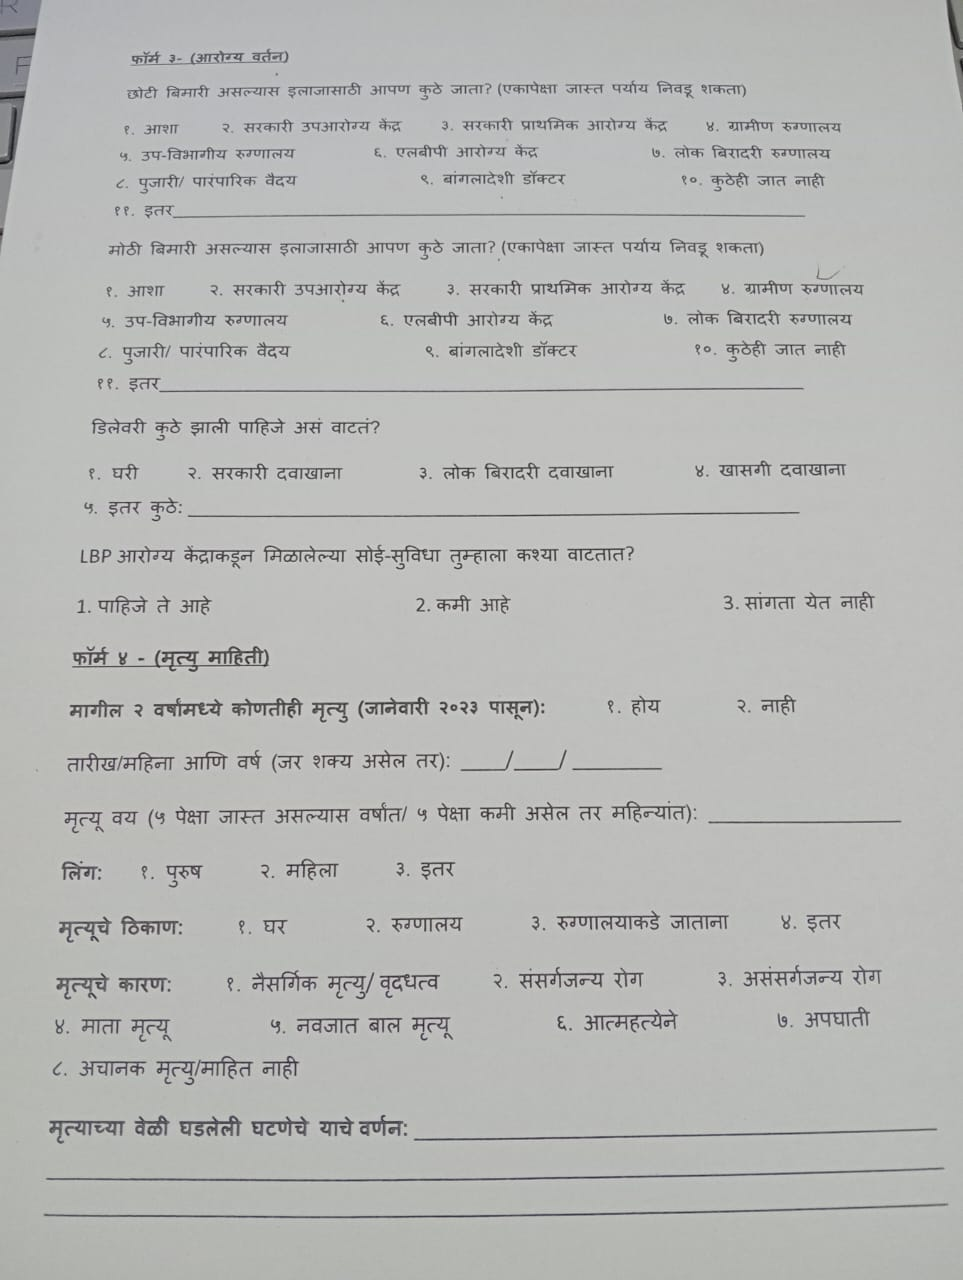

(1280, 963, 3)


In [4]:
image = cv2.imread(image_path)

cv2_imshow(image)

print(image.shape)

In [6]:
def preprocess(image):

    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    blur = cv2.GaussianBlur(
        gray,
        (5,5),
        0
    )

    thresh = cv2.threshold(
        blur,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )[1]

    return thresh

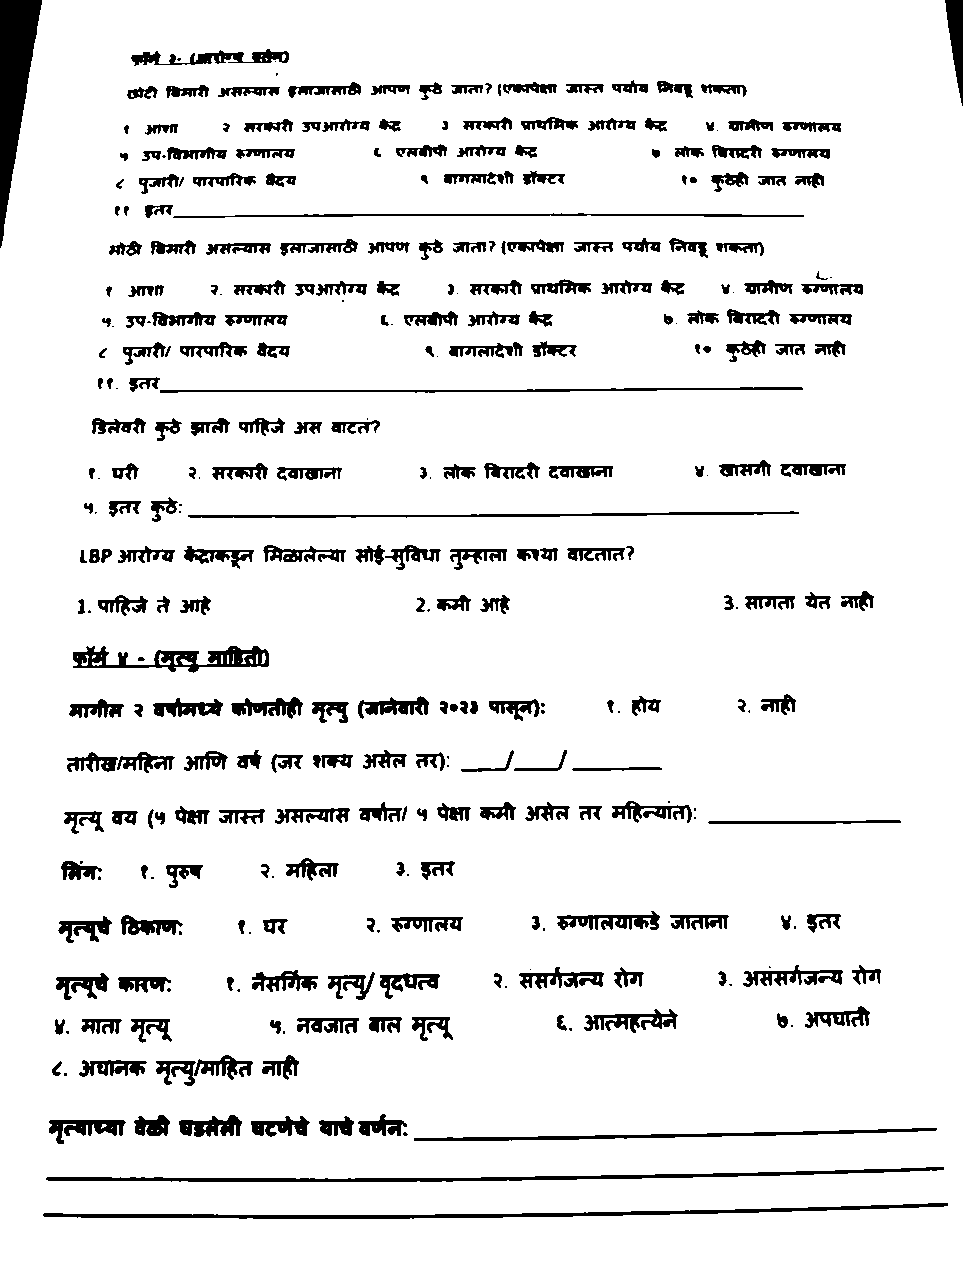

In [7]:
processed = preprocess(image)

cv2_imshow(processed)

In [12]:
import easyocr
import torch

print("CUDA:", torch.cuda.is_available())

reader = easyocr.Reader(
    ['en','hi'],
    gpu=torch.cuda.is_available()
)

print("Reader Ready")

CUDA: True
Reader Ready


In [31]:
print("Reader Loaded")
import time
import torch

print("="*50)
print("OCR STARTING")
print("="*50)

print(f"CUDA Available : {torch.cuda.is_available()}")

print("\nImage Information")
print("-----------------")
print(f"Shape : {processed.shape}")

start_time = time.time()

print("\nBeginning OCR...")
print("This may take 10-60 seconds on first run.\n")

try:

    results = reader.readtext(
    image,
    detail=1,
    paragraph=False
)

    total_time = time.time() - start_time

    print("\n")
    print("="*50)
    print("OCR COMPLETED SUCCESSFULLY")
    print("="*50)

    print(f"Execution Time : {total_time:.2f} seconds")
    print(f"Text Regions Found : {len(results)}")

    print("\nFirst 10 Results:")
    print("-----------------")

    for i, item in enumerate(results[:10], start=1):

        detected_text = item[1]
        confidence = item[2]

        print(
            f"{i}. {detected_text} "
            f"(Confidence: {confidence:.2f})"
        )

except Exception as e:

    print("\n")
    print("="*50)
    print("OCR FAILED")
    print("="*50)

    print(type(e).__name__)
    print(e)

Reader Loaded
OCR STARTING
CUDA Available : True

Image Information
-----------------
Shape : (1280, 963)

Beginning OCR...
This may take 10-60 seconds on first run.



OCR COMPLETED SUCCESSFULLY
Execution Time : 3.05 seconds
Text Regions Found : 84

First 10 Results:
-----------------
1. फॉर्स (Confidence: 0.36)
2. आरोरय वर्तन (Confidence: 0.69)
3. छोटी बिमारी असल्यास इलाजासाठी आपण (Confidence: 0.45)
4. जाता 7 (एकापेक्षा (Confidence: 0.14)
5. जारत पर्याय (Confidence: 0.44)
6. शकता ) (Confidence: 0.62)
7. आशा (Confidence: 0.72)
8. सरकारी उपआरोग्य केंद (Confidence: 0.17)
9. सरकारी प्राथमिम आरोग्य झेद (Confidence: 0.12)
10. ग्रामीण (Confidence: 0.38)


In [32]:
ocr_text = []

for item in results:

    text = item[1]

    confidence = item[2]

    ocr_text.append(text)

    print(
        f"{text} | Confidence: {confidence:.2f}"
    )

फॉर्स | Confidence: 0.36
आरोरय वर्तन | Confidence: 0.69
छोटी बिमारी असल्यास इलाजासाठी आपण | Confidence: 0.45
जाता 7 (एकापेक्षा | Confidence: 0.14
जारत पर्याय | Confidence: 0.44
शकता ) | Confidence: 0.62
आशा | Confidence: 0.72
सरकारी उपआरोग्य केंद | Confidence: 0.17
सरकारी प्राथमिम आरोग्य झेद | Confidence: 0.12
ग्रामीण | Confidence: 0.38
रग्णालय | Confidence: 0.76
उप-निभागीय रूग्णालय | Confidence: 0.47
एलनीपी आरोग्य | Confidence: 0.73
लोक चिरादरी | Confidence: 0.49
रग्णात्य | Confidence: 0.23
पारमारिक चदय | Confidence: 0.74
बांगलादेशी डाक्टर | Confidence: 0.31
जात नाहा | Confidence: 0.45
१९. इत | Confidence: 0.88
मोठी बिमारी असल्यास इलाजासाठी आपण कुठे जाता? (एकापेक्षा | Confidence: 0.34
जास्त पर्याय | Confidence: 0.41
शकता ) | Confidence: 0.56
आशा | Confidence: 0.99
२. सरकारी उपआरोग्य केंद्र | Confidence: 0.78
सरकारी प्राथमिक आरोग्य | Confidence: 0.89
गामीण रुग्णालय | Confidence: 0.50
उप विभागीय रुग्णालय | Confidence: 0.60
एलनीपी आरोग्य केंद्र | Confidence: 0.49
लोक बिरादरी रुग्णालय | C

In [33]:
import pandas as pd

df = pd.DataFrame({

    "Extracted_Text": ocr_text

})

df.head()

,Extracted_Text
0,फॉर्स
1,आरोरय वर्तन
2,छोटी बिमारी असल्यास इलाजासाठी आपण
3,जाता 7 (एकापेक्षा
4,जारत पर्याय


In [34]:
output_path = r"C:\Users\asus\OneDrive\ドキュメント\hemalkasa internship\lbp internship.xlsx"

df.to_excel(
    output_path,
    index=False
)

print("Saved:", output_path)

Saved: C:\Users\asus\OneDrive\ドキュメント\hemalkasa internship\lbp internship.xlsx


In [35]:
from google.colab import files

files.download(
    output_path
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [36]:
print(df.head(50))

                                       Extracted_Text
0                                               फॉर्स
1                                         आरोरय वर्तन
2                   छोटी बिमारी असल्यास इलाजासाठी आपण
3                                   जाता 7 (एकापेक्षा
4                                         जारत पर्याय
5                                              शकता )
6                                                 आशा
7                                सरकारी उपआरोग्य केंद
8                          सरकारी प्राथमिम आरोग्य झेद
9                                             ग्रामीण
10                                            रग्णालय
11                                उप-निभागीय रूग्णालय
12                                      एलनीपी आरोग्य
13                                        लोक चिरादरी
14                                           रग्णात्य
15                                       पारमारिक चदय
16                                  बांगलादेशी डाक्टर
17                          

In [37]:
print(ocr_text[:50])

['फॉर्स', 'आरोरय वर्तन', 'छोटी बिमारी असल्यास इलाजासाठी आपण', 'जाता 7 (एकापेक्षा', 'जारत पर्याय', 'शकता )', 'आशा', 'सरकारी उपआरोग्य केंद', 'सरकारी प्राथमिम आरोग्य झेद', 'ग्रामीण', 'रग्णालय', 'उप-निभागीय रूग्णालय', 'एलनीपी आरोग्य', 'लोक चिरादरी', 'रग्णात्य', 'पारमारिक चदय', 'बांगलादेशी डाक्टर', 'जात नाहा', '१९. इत', 'मोठी बिमारी असल्यास इलाजासाठी आपण कुठे जाता? (एकापेक्षा', 'जास्त पर्याय', 'शकता )', 'आशा', '२. सरकारी उपआरोग्य केंद्र', 'सरकारी प्राथमिक आरोग्य', 'गामीण रुग्णालय', 'उप विभागीय रुग्णालय', 'एलनीपी आरोग्य केंद्र', 'लोक बिरादरी रुग्णालय', 'पारंपारिक वैदय', 'बांगलादेशी डॉक्टर', '२०', 'जात नाही', '९२ .', 'इतर', 'डिलेवरी कुठे झाली पाहिजे असं वाटतं?', 'घरी', '२. सरकारी दवाखाना', 'लोक बिरादरी दवाखाना', 'खासगी दवाखाना', '५. इतर', 'LBP आरोग्य', 'केंद्राकडून मिळालेल्या सोई सुविधा तुम्हाला कश्या वाटतात?', '१. पाहिजे ते आहे', '२. कमी आहे', '३. सांगता येत नाही', 'फॉर्म ४ - (मृत्य माहिती)', 'मागील', 'वर्षांमध्ये कोणतीही मृत्यु (जानेवारी २०२३ पासून)ः', 'होय']


In [39]:
from openpyxl import load_workbook

excel_path = "lbp internship.xlsx"

wb = load_workbook(excel_path)

print("Workbook Loaded Successfully")
print(wb.sheetnames)

Workbook Loaded Successfully
['Sheet1']


In [38]:
ws = wb["Sheet1"]

print("Rows :", ws.max_row)
print("Columns :", ws.max_column)

print("\nFIRST 10 ROWS\n")

for row in ws.iter_rows(
    min_row=1,
    max_row=10,
    values_only=True
):
    print(row)

Rows : 102
Columns : 1

FIRST 10 ROWS

('Extracted_Text',)
('TLIIPRम',)
('aiट भिमार',)
('भमस्याम',)
('मामामामे',)
('आ्रपण फ४',)
('गाता२ पपपपता',)
('गार्त',)
('पयाय',)
('एफसा :',)
